# AI Programming Foundations Project
### Author: Patryk Pilarski
### Dataset: Titanic - Machine Learning from Disaster

This project presents a complete, reproducible data workflow using Python. In the following cells Titanic dataset will be loaded, cleaned, explored and visualized. Findings can be found at the end of the file.

#### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Load data

In [2]:
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### Check for issues in data

In [3]:
# missing values in columns Age, Cabin and Embarked
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
# Encyclopedia Titanica states that they embarked in Southampton
# https://www.encyclopedia-titanica.org/titanic-survivor/martha-evelyn-stone.html
df.loc[df['Embarked'].isna(),:]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [5]:
# multiple passengers under one ticket
df["Ticket"].value_counts().sort_values(ascending=False).head(10)

Ticket
347082          7
CA. 2343        7
1601            7
3101295         6
CA 2144         6
347088          6
382652          5
S.O.C. 14879    5
LINE            4
2666            4
Name: count, dtype: int64

In [6]:
# mostly missing values and high cardinality of cabin numbers
print(f"percent of missing values: {df["Cabin"].isna().sum() / df.shape[0]:.2f}\nnumber of unique values: {len(pd.unique(df["Cabin"]))}")

percent of missing values: 0.77
number of unique values: 148


In [7]:
# first letters of cabin numbers correspond to ship decks https://www.encyclopedia-titanica.org/titanic-deckplans/
df["Cabin"].str[:1].value_counts()

Cabin
C    59
B    47
D    33
E    32
A    15
F    13
G     4
T     1
Name: count, dtype: int64

In [8]:
# all names are unique
print(f"dataset size: {df.shape[0]}\nnumber of unique names {len(pd.unique(df["Name"]))}")

dataset size: 891
number of unique names 891


In [9]:
# limited number titles in names (need some cleaning)
df["Name"].str.extract(r" ([A-Za-z]+)\.").value_counts()

0       
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [10]:
# with many missing values for age, without more sophisticated methods,
# imputing median values from subgroups seems like the best approach
# (removing almost 200 rows from 900 rows dataset seems too drastic)
df.groupby(["Pclass", "Sex"])["Age"].describe()

count       mean        std   min     25%   50%    75%   max
Pclass Sex                                                                 
1      female   85.0  34.611765  13.612052  2.00  23.000  35.0  44.00  63.0
       male    101.0  41.281386  15.139570  0.92  30.000  40.0  51.00  80.0
2      female   74.0  28.722973  12.872702  2.00  22.250  28.0  36.00  57.0
       male     99.0  30.740707  14.793894  0.67  23.000  30.0  36.75  70.0
3      female  102.0  21.750000  12.729964  0.75  14.125  21.5  29.75  63.0
       male    253.0  26.507589  12.159514  0.42  20.000  25.0  33.00  74.0

#### Data cleaning functions

In [11]:
def transform_embarked(df: pd.DataFrame) -> pd.DataFrame:
    """
    Transform Embarked column. Fill missing values for passengers
    with ticket '113572' and map codes to port names.
    """
    df_ = df.copy()
    df_.loc[df["Ticket"] == "113572", "Embarked"] = "S"
    df_["Embarked"] = df_["Embarked"].map({"C": "Cherbourg", "Q": "Queenstown", "S": "Southampton"})
    return df_

In [12]:
def replace_cabin_with_deck(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create Deck column from values extracted from cabin number,
    fill missing values and rare cases for deck with 'X' and remove Cabin column.
    """
    df_ = df.copy()
    df_["Deck"] = df_["Cabin"].str[:1]
    df_["Deck"] = df_["Deck"].fillna("X")
    df_["Deck"] = df_["Deck"].replace({"T": "X", "G": "X"})
    df_.drop(columns=["Cabin"], inplace=True)
    return df_

In [13]:
def add_companions_count(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create Companions column based on the number of people under the same ticket.
    In some cases passengers traveled with people other than faimily
    """
    df_ = df.copy()
    df_["Companions"] = df_.groupby("Ticket")["Ticket"].transform("count") - 1
    return df_

In [14]:
def extract_title(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create column Title with values extracted from names. Reduce title cardinality
    by remapping rare cases to more common classes.
    """
    df_ = df.copy()
    title_map = {
        "Mlle": "Miss", "Ms": "Mrs", "Mme": "Mrs", "Lady": "Noble", "Countess": "Noble",
        "Don": "Noble", "Dona": "Noble", "Jonkheer": "Noble", "Sir": "Noble", "Rev": "Noble",
        "Major": "Noble", "Col": "Noble", "Capt": "Noble", "Dr": "Noble"
    }
    df_["Title"] = df_["Name"].str.extract(r" ([A-Za-z]+)\.")
    df_["Title"] = df_["Title"].replace(title_map)
    return df_

In [15]:
def fill_missing_age(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    """
    Fill missing values in Age column with median values from groups defined by group_cols.
    """
    df_ = df.copy()
    df_["tmp"] = df_.groupby(group_cols)["Age"].transform("median")
    df_["Age"] = df_["Age"].fillna(df_["tmp"])
    df_.drop(columns=["tmp"], inplace=True)
    return df_

In [16]:
def add_female_col(df: pd.DataFrame, sex_col: str = "Sex", out_col: str = "Female") -> pd.DataFrame:
    """Add binary column indicating if passenger was female."""
    df_ = df.copy()
    df_[out_col] = pd.factorize(df_[sex_col])[0]
    return df_

In [17]:
def drop_cols(df: pd.DataFrame, cols_to_drop: list[str]) -> pd.DataFrame:
    """Remove redundant columns."""
    df_ = df.copy()
    df_.drop(columns=cols_to_drop, inplace=True)
    return df_

#### Data cleaning

In [18]:
df_clean = transform_embarked(df)
df_clean = replace_cabin_with_deck(df_clean)
df_clean = add_companions_count(df_clean)
df_clean = extract_title(df_clean)
df_clean = fill_missing_age(df_clean, ["Pclass", "Sex", "Deck", "Title"])
df_clean = add_female_col(df_clean)
df_clean = drop_cols(df_clean, ["PassengerId", "Name", "Ticket", "Sex"])
df_clean.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked,Deck,Companions,Title,Female
0,0,3,22.0,1,0,7.2500,Southampton,X,0,Mr,0
1,1,1,38.0,1,0,71.2833,Cherbourg,C,0,Mrs,1
2,1,3,26.0,0,0,7.9250,Southampton,X,0,Miss,1
3,1,1,35.0,1,0,53.1000,Southampton,C,1,Mrs,1
4,0,3,35.0,0,0,8.0500,Southampton,X,0,Mr,0


#### EDA functions

In [19]:
def summarize_data(df: pd.DataFrame, num_cols: list[str], cat_cols: list[str]) -> None:
    """Calculate summary statistics and value counts for columns."""
    print("CATEGORICAL COLUMNS:\n")
    for col in cat_cols:
        print(df[col].value_counts())
        print("-" * 10)
    print("\nNUMERICAL COLUMNS:\n")
    print(df[num_cols].describe())

In [20]:
def calculate_correlations(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """Calculate correlations between selected columns."""
    return df[cols].corr()

In [21]:
def calculate_survival_rate(
    df: pd.DataFrame, group_cols: list[str], survived_col: str = "Survived", add_count: bool = True
) -> pd.DataFrame:
    """Calculate survival rate for groups."""
    if add_count:
        out = pd.DataFrame(df.groupby(group_cols).agg(survival_rate=(survived_col, "mean"), count=(survived_col, "count"))).reset_index()
    else:
        out = pd.DataFrame(df.groupby(group_cols).agg(survival_rate=(survived_col, "mean"))).reset_index()
    return out

#### EDA

In [22]:
# some numeric columns included into categorical columns list as they have low cardinality and counts are more informative
summarize_data(df_clean, ["Age", "Fare"], ["Survived", "Pclass", "Female", "Embarked", "Deck", "Title", "SibSp", "Parch", "Companions"])

CATEGORICAL COLUMNS:

Survived
0    549
1    342
Name: count, dtype: int64
----------
Pclass
3    491
1    216
2    184
Name: count, dtype: int64
----------
Female
0    577
1    314
Name: count, dtype: int64
----------
Embarked
Southampton    646
Cherbourg      168
Queenstown      77
Name: count, dtype: int64
----------
Deck
X    692
C     59
B     47
D     33
E     32
A     15
F     13
Name: count, dtype: int64
----------
Title
Mr        517
Miss      184
Mrs       127
Master     40
Noble      23
Name: count, dtype: int64
----------
SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64
----------
Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64
----------
Companions
0    547
1    188
2     63
3     44
6     21
5     18
4     10
Name: count, dtype: int64
----------

NUMERICAL COLUMNS:

              Age        Fare
count  890.000000  891.000000
mean    29.177438   32.204208
std     13.532079   49.693

In [23]:
corr_df = calculate_correlations(df_clean, ["Survived", "Age", "SibSp", "Parch", "Fare", "Companions", "Female"])
corr_df

,Survived,Age,SibSp,Parch,Fare,Companions,Female
Survived,1.000000,-0.059826,-0.035322,0.081629,0.257307,0.038247,0.543351
Age,-0.059826,1.000000,-0.269633,-0.184370,0.123215,-0.234715,-0.098701
SibSp,-0.035322,-0.269633,1.000000,0.414838,0.159651,0.661622,0.114631
Parch,0.081629,-0.184370,0.414838,1.000000,0.216225,0.593076,0.245489
Fare,0.257307,0.123215,0.159651,0.216225,1.000000,0.345541,0.182333
Companions,0.038247,-0.234715,0.661622,0.593076,0.345541,1.000000,0.154748
Female,0.543351,-0.098701,0.114631,0.245489,0.182333,0.154748,1.000000


In [24]:
calculate_survival_rate(df_clean, ["Title", "Female"])

,Title,Female,survival_rate,count
0,Master,0,0.575000,40
1,Miss,1,0.701087,184
2,Mr,0,0.156673,517
3,Mrs,1,0.795276,127
4,Noble,0,0.250000,20
5,Noble,1,1.000000,3


In [25]:
calculate_survival_rate(df_clean, ["Pclass", "Deck"])

,Pclass,Deck,survival_rate,count
0,1,A,0.466667,15
1,1,B,0.744681,47
2,1,C,0.593220,59
3,1,D,0.758621,29
4,1,E,0.720000,25
5,1,X,0.463415,41
6,2,D,0.750000,4
7,2,E,0.750000,4
8,2,F,0.875000,8
9,2,X,0.440476,168


In [26]:
calculate_survival_rate(df_clean, ["Embarked"])

,Embarked,survival_rate,count
0,Cherbourg,0.553571,168
1,Queenstown,0.389610,77
2,Southampton,0.339009,646


#### Visualizations

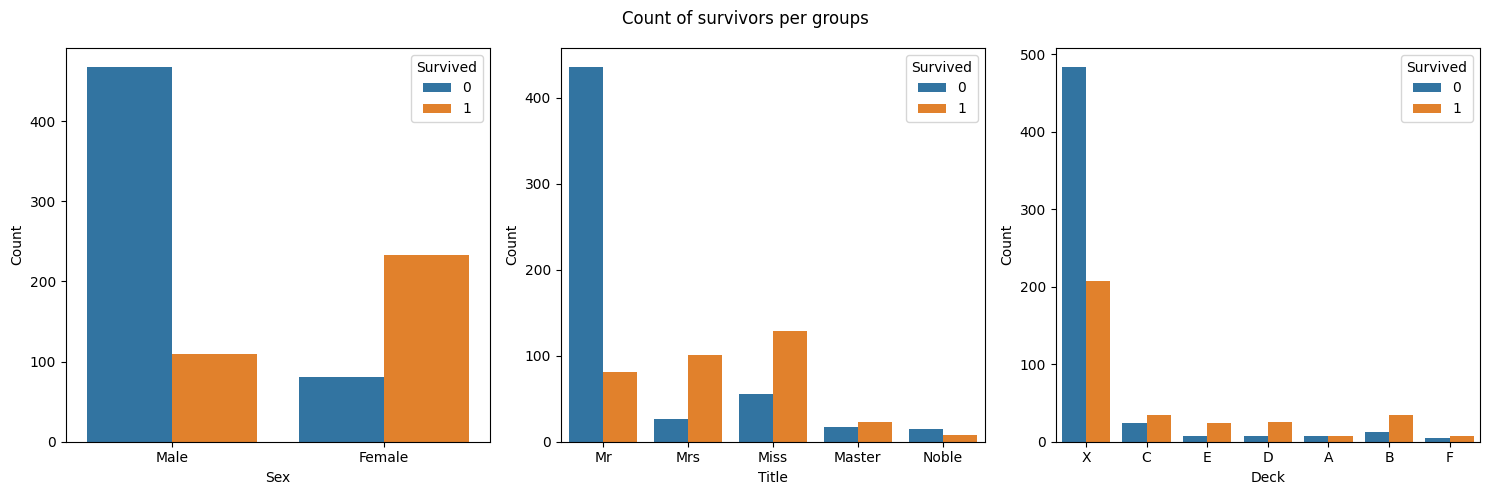

In [27]:
fig, axis = plt.subplots(1, 3, figsize = (15, 5))

sns.countplot(ax=axis[0], data=df_clean, x="Female", hue="Survived")
axis[0].set_xticks([0, 1], ["Male", "Female"])
axis[0].set_xlabel("Sex")
axis[0].set_ylabel("Count")
sns.countplot(ax=axis[1], data=df_clean, x="Title", hue="Survived").set(ylabel = None)
axis[1].set_ylabel("Count")
sns.countplot(ax=axis[2], data=df_clean, x="Deck", hue="Survived").set(ylabel = None)
axis[2].set_ylabel("Count")
fig.suptitle("Count of survivors per groups")
plt.tight_layout()
plt.show()

Most survivors were female, grouping by titles seems to only strenghten this insight. Interestingly the highest number of casualties was among passengers for whom deck (cabin) was not known.

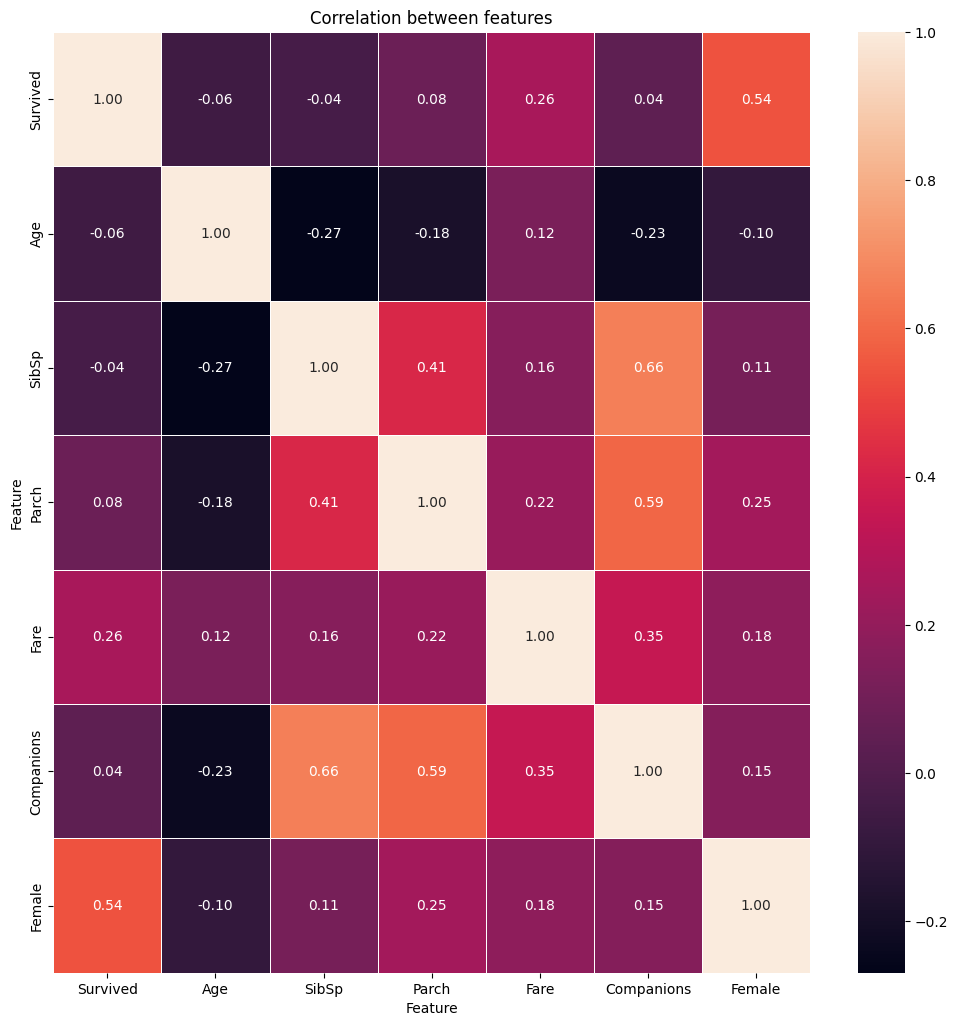

In [28]:
fig, axis = plt.subplots(figsize = (10, 10))

sns.heatmap(corr_df, annot=True, fmt=".2f", linewidths=0.6)
plt.tight_layout()
plt.title("Correlation between features")
plt.xlabel("Feature")
plt.ylabel("Feature")
plt.show()

Sex (being female) has the strongest correlation with survival, but it's only moderately strong correlation

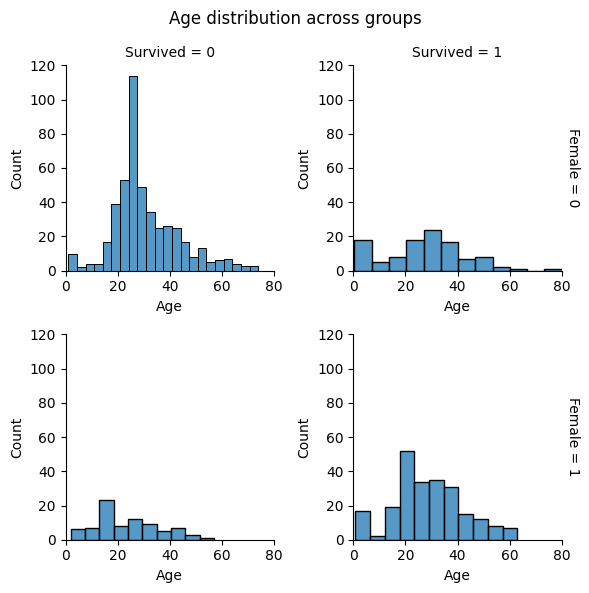

In [29]:
g = sns.FacetGrid(data=df_clean, row="Female", col="Survived", margin_titles=True, sharex=False, sharey=False)
g.map(sns.histplot, "Age")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Age distribution across groups")
g.axes[0,0].set_xlabel("Sex")
for axes in g.axes:
    for ax in axes:
        ax.set_xlabel("Age")
        ax.set_ylabel("Count")
        ax.set_xlim(0, 80)
        ax.set_ylim(0, 120)
g.tight_layout()
plt.show()

As can be seen above most casualties were among young men in their 20s. Casualties among women are more evenly spread across age brackets

#### Summary

Raw dataset contained 891 rows and 12 columns. It required some cleaning and handling of missing values. Fortunately it was possible to preserve all rows by filling missing values. Process of filling missing values could most likely be further improved by consulting [Encyclopedia Titanica](https://www.encyclopedia-titanica.org) which contains a lot of usefull information about the ship and its final voyage (two missing values were already replaced with data coming from this source). If the end goal of data processing would be ML model training data would need to be wrangled a bit more to properly encode categorical columns etc.

Since Titanic disaster is a well studied topic, insights coming from the analysis are not groundbreaking, but it's worth mentioning that:
- female passangers had much higher chances of survival
- highest number of casualties were males of around 20 years of age (exact counts should be taken with a grain of salt as there were 177 missing values that were replaced by median values per groups)
- for most of the passangers, cabin number was missing in the dataset (cabin number allows to link the person with particular deck, and each deck had different disatnce to lifeboats which were crucial for survival)
- passengers who embarked on the voyage in Cherbourg had higher chance of survival than ones that boarded the ship in Queenstown or Southampton
- most passengers traveled alone, but there were also cases of bigger parties (families, friends or well-off people traveling with their entourage)

Main limitations when it comes to data cleaning in this case arise from the missing values present in the original dataset, mainly in `Age` and `Cabin` columns. Missing values in `Age` column were filled with median values per groups defined by columns: `Pclass`, `Sex`, `Deck` and `Title` - this approach seemed to be the best one that didn't require neither extensive manual work (by searching for missing data in Encyclopedia Titanica) nor employing more complex predictive models. Missing values in `Cabin` could not be filled using simple heauristics or models - the only way to fill those values would be to consult Encyclopedia Titanica (or other sources).

One surprising thing when it comes to `Cabin` column is the presence of value starting with `T`, it's unclear what does it represent as there was no `T` deck on Titanic.